**The Random Forest Baseline**
- **Dataset:** from sklearn.datasets import load_breast_cancer
- **Objective:** Understand the standard implementation and advantage of bagging.
- **Task:** Use scikit-learn to train a single DecisionTreeClassifier and a RandomForestClassifier on a standard dataset (like the Breast Cancer or Titanic dataset).
- **Requirements:**
                - Evaluate both models using Accuracy, Precision, Recall, and F1-score 
                - Plot the Feature Importances extracted from the Random Forest model.
                - Question to answer: How does the Random Forest mitigate the overfitting typically seen in deep, unpruned decision trees?

--- Model Performance Comparison ---
               Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9181     0.9346  0.9346    0.9346
Random Forest    0.9357     0.9444  0.9533    0.9488




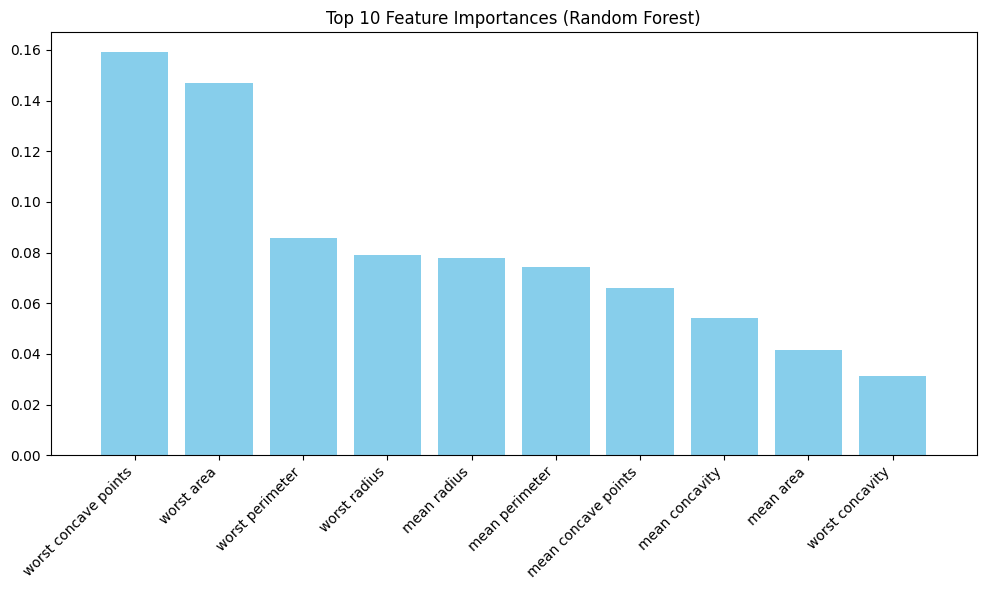

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split into training and testing sets (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Initialize and train the models
# We leave the decision tree unpruned (no max_depth) to demonstrate potential overfitting
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 3. Evaluate both models
models = {"Decision Tree": dt_model, "Random Forest": rf_model}
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

# Display metrics as a DataFrame
metrics_df = pd.DataFrame(metrics).T
print("--- Model Performance Comparison ---")
print(metrics_df.round(4))
print("\n")

# 4. Plot Feature Importances from Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Select top 10 features for cleaner visualization
top_n = 10
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.bar(range(top_n), importances[indices[:top_n]], align="center", color="skyblue")
plt.xticks(range(top_n), [data.feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()

**Building a Bagging Meta-Estimator**
- **Dataset:** from sklearn.datasets import load_breast_cancer
- **Objective:** Understand how bootstrap sampling works under the hood.
- **Task:** Instead of using RandomForestClassifier, use scikit-learn's BaggingClassifier wrapper.
- **Requirements:**
               - Use a high-variance model (like a deep Decision Tree) and a low-variance model (like Logistic Regression) as the base estimators for two separate Bagging Classifiers.
               - Experiment with the max_samples and max_features hyperparameters.
               - Analyze how bagging affects the performance of the high-variance vs. low-variance base estimators differently.

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load and prepare the dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Define Base Estimators
# High-variance model: Deep, unpruned decision tree
dt_base = DecisionTreeClassifier(random_state=42)

# Low-variance model: Logistic Regression (scaled to ensure convergence)
lr_base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# 3. Define Bagging Configurations to Experiment With
# Config 1: Standard Bagging (100% rows with replacement, 100% features)
# Config 2: Subspace Bagging (80% rows with replacement, 60% features)
configs = [
    {"name": "Standard (1.0 Rows, 1.0 Feat)", "max_samples": 1.0, "max_features": 1.0},
    {"name": "Subspace (0.8 Rows, 0.6 Feat)", "max_samples": 0.8, "max_features": 0.6}
]

results = []

# Evaluate standalone base models first for reference
for name, model in [("Standalone Decision Tree", dt_base), ("Standalone Logistic Reg", lr_base)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model Type": name,
        "Configuration": "N/A",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Evaluate Bagging Classifiers
for config in configs:
    for base_name, base_model in [("Bagged Tree", dt_base), ("Bagged Logistic Reg", lr_base)]:
        bagging_clf = BaggingClassifier(
            estimator=base_model,
            n_estimators=100,
            max_samples=config["max_samples"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        )
        bagging_clf.fit(X_train, y_train)
        y_pred = bagging_clf.fit(X_train, y_train).predict(X_test)
        
        results.append({
            "Model Type": base_name,
            "Configuration": config["name"],
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred)
        })

# Display Results
results_df = pd.DataFrame(results)
print("--- Bagging Meta-Estimator Experiment Results ---")
print(results_df.to_string(index=False))

--- Bagging Meta-Estimator Experiment Results ---
              Model Type                 Configuration  Accuracy  Precision   Recall  F1-Score
Standalone Decision Tree                           N/A  0.918129   0.934579 0.934579  0.934579
 Standalone Logistic Reg                           N/A  0.988304   0.990654 0.990654  0.990654
             Bagged Tree Standard (1.0 Rows, 1.0 Feat)  0.947368   0.945455 0.971963  0.958525
     Bagged Logistic Reg Standard (1.0 Rows, 1.0 Feat)  0.988304   0.990654 0.990654  0.990654
             Bagged Tree Subspace (0.8 Rows, 0.6 Feat)  0.953216   0.945946 0.981308  0.963303
     Bagged Logistic Reg Subspace (0.8 Rows, 0.6 Feat)  0.982456   0.981481 0.990654  0.986047
